# One-shot pruning ResNet50 / CIFAR-10: inherited против scratch

Этот отчёт разбирает полный протокол `dense150 → adaptive search60 → inherited90 / scratch90`.
Checkpoint и маска выбираются только по validation; официальный test показывается лишь тогда,
когда существует отдельный замороженный `test_evaluation/test_summary.json`.

Главный диагностический вопрос: почему gated checkpoint имел **93,56% validation accuracy**,
а физическая модель сразу после экспорта — **10,28%**. Под «нулевой compact-моделью» здесь
понимается compact architecture на recovery-эпохе 0, до какого-либо дообучения. Это не модель
с нулём параметров и не финальный deployment.

In [1]:
from pathlib import Path
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 50)
pd.set_option('display.precision', 5)

ROOT = Path.cwd().resolve()
configured = os.environ.get('ONE_SHOT_RUN_DIR')
RUN_DIR = Path(configured).expanduser().resolve() if configured else (
    ROOT / 'outputs/runs/one_shot_60_90_inherited_vs_scratch').resolve()
REFERENCE_DIR = RUN_DIR.parent / 'one_shot_dense_reference_seed42/J1_dense_control'

assert RUN_DIR.is_dir(), f'Run directory not found: {RUN_DIR}'
assert REFERENCE_DIR.is_dir(), f'Dense reference directory not found: {REFERENCE_DIR}'

def read_json(path):
    return json.loads(Path(path).read_text())

def only(pattern):
    found = list(RUN_DIR.glob(pattern))
    assert len(found) == 1, (pattern, found)
    return found[0]

state = read_json(RUN_DIR / 'one_shot_state.json')
comparison = read_json(RUN_DIR / 'comparison.json')
selection = read_json(RUN_DIR / 'selection.json')
diagnostics = read_json(RUN_DIR / 'export_only/diagnostics.json')
reference_state = read_json(REFERENCE_DIR / 'pilot_state.json')

dense = pd.read_csv(REFERENCE_DIR / 'global_history.csv')
search = pd.read_csv(only('shared_search/training/*/history.csv'))
inherited = pd.read_csv(only('inherited/training/*/history.csv'))
scratch = pd.read_csv(only('scratch/training/*/history.csv'))

assert state['status'] == 'completed'
assert len(dense) == 150 and len(search) == 60
assert len(inherited) == len(scratch) == 90
print('Run:', RUN_DIR.name)
print('Commit:', state['provenance']['code']['commit'], 'dirty=', state['provenance']['code']['dirty'])
print('Official test saved:', (RUN_DIR / 'test_evaluation/test_summary.json').is_file())

Run: one_shot_60_90_inherited_vs_scratch
Commit: 552f26e4561967205abe85a4d355d77695dfd09a dirty= False
Official test saved: False


## 1. Итоговые validation-модели и физический размер

Каждая строка ниже относится к validation-selected checkpoint. Все 90 recovery-эпох были
фактически выполнены, даже если лучший checkpoint выбран раньше. Dense также выполнил все
150 эпохи и выбрал epoch 140 по validation.

In [2]:
dense_cost = reference_state['final_cost']
rows = [{
    'model': 'dense reference',
    'selected_epoch': reference_state['selected_epoch'],
    'validation_accuracy_pct': 100 * reference_state['validation']['accuracy'],
    'validation_ce': reference_state['validation']['ce_loss'],
    'correct_of_5000': reference_state['validation']['correct_count'],
    'parameters': dense_cost['physical_total_parameters'],
    'GMAC_per_image': dense_cost['conv_linear_macs_per_image'] / 1e9,
}]
for branch in ('inherited', 'scratch'):
    record = state['branches'][branch]
    rows.append({
        'model': branch,
        'selected_epoch': record['selected_final_epoch'],
        'validation_accuracy_pct': 100 * record['validation']['accuracy'],
        'validation_ce': record['validation']['ce_loss'],
        'correct_of_5000': record['validation']['correct_count'],
        'parameters': record['final_cost']['physical_total_parameters'],
        'GMAC_per_image': record['final_cost']['conv_linear_macs_per_image'] / 1e9,
    })
summary = pd.DataFrame(rows).set_index('model')
summary['delta_vs_dense_pp'] = summary.validation_accuracy_pct - summary.loc['dense reference', 'validation_accuracy_pct']
summary['parameter_reduction_pct'] = 100 * (1 - summary.parameters / summary.loc['dense reference', 'parameters'])
summary['MAC_reduction_pct'] = 100 * (1 - summary.GMAC_per_image / summary.loc['dense reference', 'GMAC_per_image'])
display(summary)
print(f"Inherited − scratch: {summary.loc['inherited', 'validation_accuracy_pct'] - summary.loc['scratch', 'validation_accuracy_pct']:+.2f} п.п.")

,selected_epoch,validation_accuracy_pct,validation_ce,correct_of_5000,parameters,GMAC_per_image,delta_vs_dense_pp,parameter_reduction_pct,MAC_reduction_pct
model,,,,,,,,,
dense reference,140,94.64,0.48750,4732,23547338,1.29783,0.00,0.00000,0.00000
inherited,75,94.38,0.46664,4719,17321706,1.19393,-0.26,26.43879,8.00571
scratch,89,93.82,0.46409,4691,17321706,1.19393,-0.82,26.43879,8.00571


Inherited − scratch: +0.56 п.п.


## 2. Полная временная шкала

Recovery-кривые расположены после общего search: их локальная эпоха 1 показана как глобальная 61.
Звёзды обозначают выбранные validation-checkpoint’ы. Красная точка при epoch 60 — физический
экспорт **до recovery**.

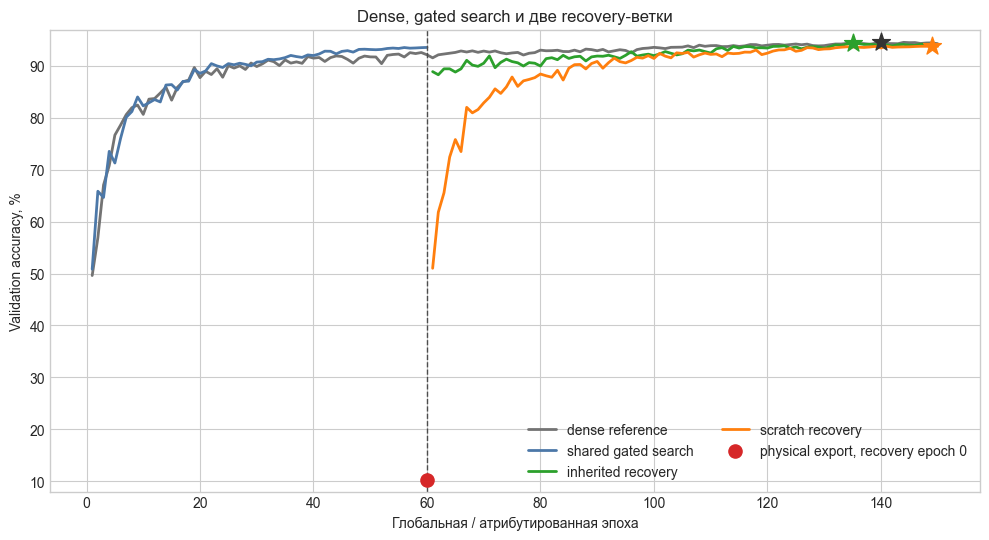

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(dense.global_epoch, 100 * dense.valid_accuracy, color='0.45', lw=2, label='dense reference')
ax.plot(search.epoch, 100 * search.valid_accuracy, color='#4C78A8', lw=2, label='shared gated search')
ax.plot(60 + inherited.epoch, 100 * inherited.valid_accuracy, color='#2CA02C', lw=2, label='inherited recovery')
ax.plot(60 + scratch.epoch, 100 * scratch.valid_accuracy, color='#FF7F0E', lw=2, label='scratch recovery')
ax.scatter([60], [100 * diagnostics['physical_validation']['accuracy']], s=90, color='#D62728', zorder=5,
           label='physical export, recovery epoch 0')
ax.scatter([reference_state['selected_epoch']], [100 * reference_state['validation']['accuracy']],
           marker='*', s=180, color='0.2', zorder=6)
for branch, frame, color in [('inherited', inherited, '#2CA02C'), ('scratch', scratch, '#FF7F0E')]:
    e = state['branches'][branch]['selected_final_epoch']
    y = frame.loc[frame.epoch.eq(e), 'valid_accuracy'].iloc[0]
    ax.scatter([60 + e], [100 * y], marker='*', s=180, color=color, zorder=6)
ax.axvline(60, ls='--', color='0.3', lw=1)
ax.set(xlabel='Глобальная / атрибутированная эпоха', ylabel='Validation accuracy, %',
       title='Dense, gated search и две recovery-ветки')
ax.set_ylim(8, 97)
ax.legend(ncol=2, loc='lower right')
plt.show()

## 3. Что означает «нулевая compact-модель неработоспособна»

Search-checkpoint использует бинарные gates. К epoch 60 контроллер закрыл 1 603 внутренних
координаты. Физически удалось удалить 1 114. Ещё **489 hard-closed координат** пришлось оставить
из-за `min_keep_ratio=0.5` и зависимостей архитектуры. После удаления gate-модулей эти оставшиеся
координаты становятся открытыми.

Поэтому physical export не реализует ту же функцию, что выбранный gated predictor:

- gated validation: 93,56%;
- physical validation до recovery: 10,28%;
- disagreement предсказаний: 90,32%;
- physical CE: 1640,58.

Проверка all-open tensor transfer прошла `passed_fp32`, поэтому это не повреждение checkpoint и
не неправильное копирование Conv/BN. Это ожидаемое следствие текущего handoff: закрытые, но
структурно неудаляемые survivors вновь открываются. Следовательно, этот запуск доказывает поиск
архитектуры с последующим recovery, но не function-preserving export готовой модели.

,accuracy_pct,ce_loss
state,,
selected gated search,93.56,0.45981
"physical export, epoch 0",10.28,1640.57892
"inherited, recovery epoch 1",88.90,0.41368
"scratch, recovery epoch 1",51.02,1.35978


Hard-closed candidates: 1603
Physically removed: 1114
Hard-closed survivors reopened: 489


,reopened_channels
backbone.layer4.2.mid1_gumbel_layer,243
backbone.layer4.2.mid2_gumbel_layer,230
backbone.layer4.1.mid1_gumbel_layer,16


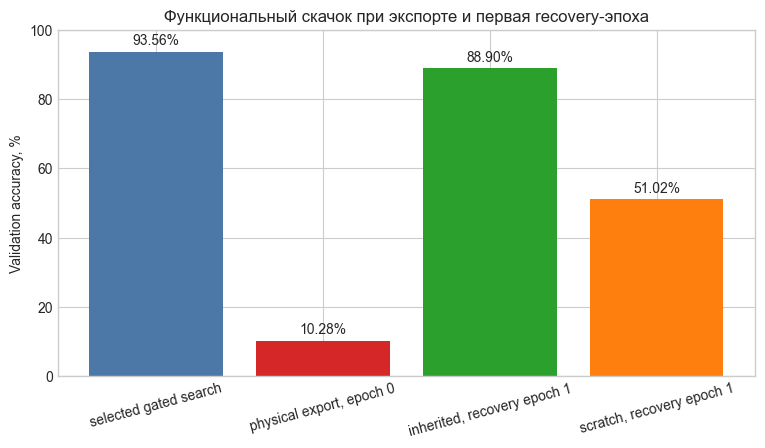

In [4]:
export_rows = pd.DataFrame([
    {'state': 'selected gated search', **diagnostics['gated_validation']},
    {'state': 'physical export, epoch 0', **diagnostics['physical_validation']},
    {'state': 'inherited, recovery epoch 1',
     'accuracy': inherited.iloc[0].valid_accuracy, 'ce_loss': inherited.iloc[0].valid_ce_loss},
    {'state': 'scratch, recovery epoch 1',
     'accuracy': scratch.iloc[0].valid_accuracy, 'ce_loss': scratch.iloc[0].valid_ce_loss},
]).set_index('state')
export_rows['accuracy_pct'] = 100 * export_rows.accuracy
display(export_rows[['accuracy_pct', 'ce_loss']])

blocked = pd.Series([x['boundary'] for x in diagnostics['blocked_closed_survivors_opened_by_export']]).value_counts()
print('Hard-closed candidates:', selection['trace']['trace'][-1]['selector']['eligible'].__len__())
print('Physically removed:', sum(map(len, selection['pruning_mask'].values())))
print('Hard-closed survivors reopened:', int(blocked.sum()))
display(blocked.rename('reopened_channels').to_frame())

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(export_rows.index, export_rows.accuracy_pct, color=['#4C78A8', '#D62728', '#2CA02C', '#FF7F0E'])
ax.bar_label(bars, fmt='%.2f%%', padding=3)
ax.set(ylabel='Validation accuracy, %', title='Функциональный скачок при экспорте и первая recovery-эпоха')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=15)
plt.show()

## 4. Adaptive lambda и рост физического сжатия

Lambda удваивалась по accuracy-only правилу с 0,001 до 65,536. Физическое удаление началось
на epoch 25; минимальный размер достигнут на epochs 58–60. Среди одинаково компактных
checkpoint’ов выбран epoch 60 по лучшей validation accuracy/CE.

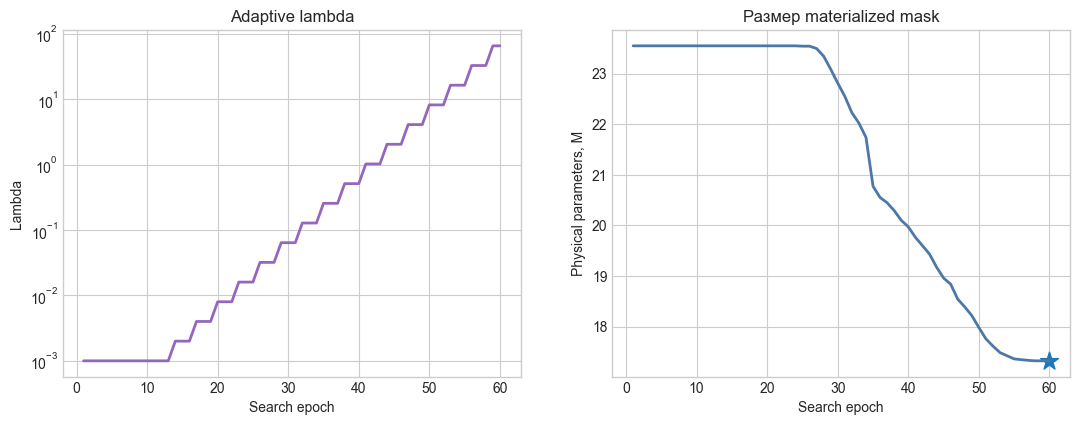

,epoch,valid_accuracy,lambda_used,lambda_next,adaptive_lambda_reason
12,13,0.8306,0.001,0.002,mean_gap_within_soft_drop
15,16,0.8536,0.002,0.004,mean_gap_within_soft_drop
18,19,0.8930,0.004,0.008,mean_gap_within_soft_drop
21,22,0.9044,0.008,0.016,mean_gap_within_soft_drop
24,25,0.9044,0.016,0.032,mean_gap_within_soft_drop
27,28,0.9030,0.032,0.064,mean_gap_within_soft_drop
30,31,0.9082,0.064,0.128,mean_gap_within_soft_drop
33,34,0.9134,0.128,0.256,mean_gap_within_soft_drop
36,37,0.9180,0.256,0.512,mean_gap_within_soft_drop
39,40,0.9200,0.512,1.024,mean_gap_within_soft_drop


In [5]:
trace = pd.DataFrame([{
    'epoch': row['epoch'], 'accuracy': row['accuracy'], 'physical_parameters': row['physical_cost'],
    'removed_parameters': row['selector']['removed_params'],
} for row in selection['trace']['trace']])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(search.epoch, search.lambda_used, color='#9467BD', lw=2)
axes[0].set_yscale('log')
axes[0].set(xlabel='Search epoch', ylabel='Lambda', title='Adaptive lambda')
axes[1].plot(trace.epoch, trace.physical_parameters / 1e6, color='#4C78A8', lw=2)
axes[1].scatter([selection['selected_epoch']], [trace.iloc[-1].physical_parameters / 1e6], marker='*', s=180)
axes[1].set(xlabel='Search epoch', ylabel='Physical parameters, M', title='Размер materialized mask')
plt.show()

updates = search.loc[search.adaptive_lambda_action.eq('increase_lambda'),
                     ['epoch', 'valid_accuracy', 'lambda_used', 'lambda_next', 'adaptive_lambda_reason']]
display(updates)

## 5. Где произошло удаление

Почти всё удаление сосредоточено в `layer4`: это даёт заметное сокращение параметров, но слабое
сокращение MACs, потому что поздние feature maps имеют маленькое пространственное разрешение.

,boundary,removed,stage
0,backbone.layer4.2.mid1_gumbel_layer,256,layer4
1,backbone.layer4.2.mid2_gumbel_layer,256,layer4
3,backbone.layer4.1.mid1_gumbel_layer,256,layer4
2,backbone.layer4.1.mid2_gumbel_layer,206,layer4
4,backbone.layer4.0.mid2_gumbel_layer,74,layer4
5,backbone.layer4.0.mid1_gumbel_layer,56,layer4
6,backbone.layer3.5.mid2_gumbel_layer,7,layer3
8,backbone.layer3.5.mid1_gumbel_layer,2,layer3
7,backbone.layer3.4.mid2_gumbel_layer,1,layer3


,removed,share_pct
stage,,
layer4,1104,99.10233
layer3,10,0.89767


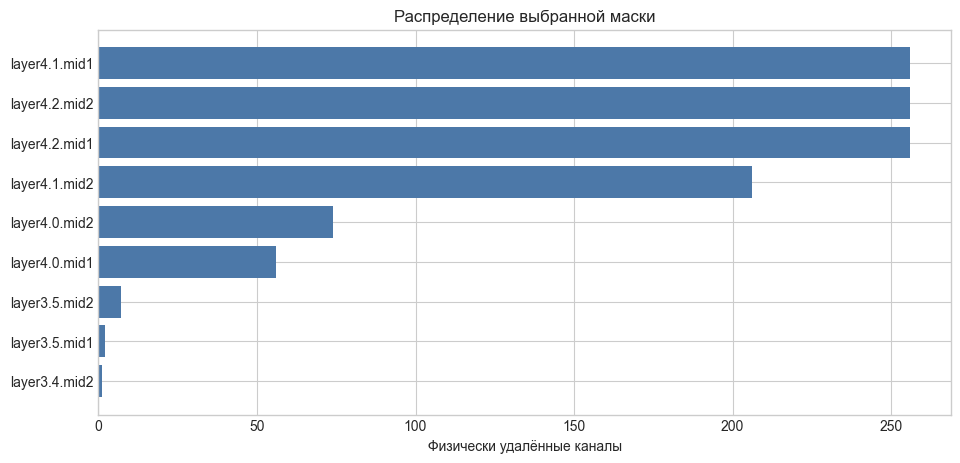

In [6]:
removed = pd.Series({name: len(ids) for name, ids in selection['pruning_mask'].items()}, name='removed')
layers = removed.rename_axis('boundary').reset_index()
layers['stage'] = layers.boundary.str.extract(r'(layer\d)').iloc[:, 0]
stage_removed = layers.groupby('stage', sort=False).removed.sum().to_frame()
stage_removed['share_pct'] = 100 * stage_removed.removed / stage_removed.removed.sum()
display(layers.sort_values('removed', ascending=False))
display(stage_removed)

fig, ax = plt.subplots(figsize=(11, 5))
ordered = layers.sort_values('removed')
ax.barh(ordered.boundary.str.replace('backbone.', '', regex=False).str.replace('_gumbel_layer', '', regex=False),
        ordered.removed, color='#4C78A8')
ax.set(xlabel='Физически удалённые каналы', title='Распределение выбранной маски')
plt.show()

## 6. Скорость recovery: inherited против scratch

Inherited начинает с перенесённых surviving Conv/BN tensors, scratch — с новой PyTorch
инициализации той же физической архитектуры. Поэтому сравнение отвечает на вопрос о пользе
наследования весов, а не о разных масках: architecture hash, mask и стоимость совпадают.

,inherited,scratch
validation threshold,,
90.0%,7,26.0
92.0%,24,41.0
93.0%,46,58.0
93.5%,52,67.0
94.0%,72,NaN


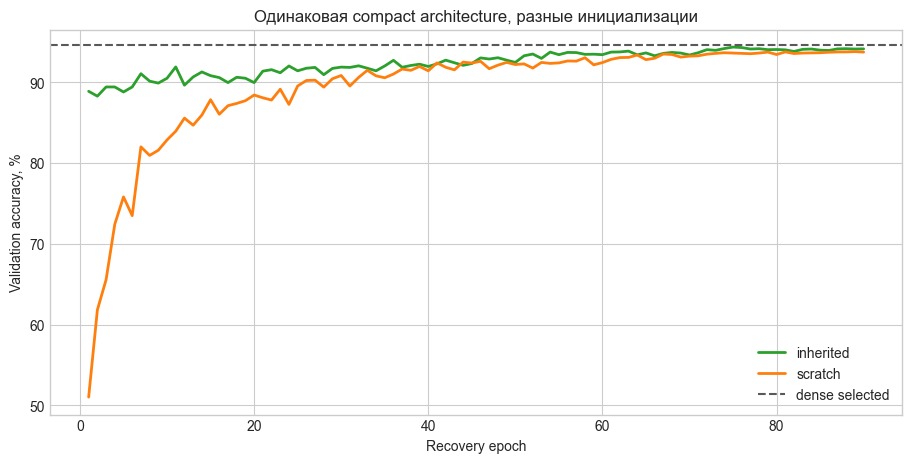

Inherited выше на 87/90 соответствующих эпохах.
Средняя разница на последних 30 эпохах: +0.445 п.п.


In [7]:
def first_crossing(frame, threshold):
    hit = frame.loc[frame.valid_accuracy.ge(threshold), 'epoch']
    return int(hit.iloc[0]) if len(hit) else None

thresholds = pd.DataFrame({
    branch: {f'{100*t:.1f}%': first_crossing(frame, t) for t in (0.90, 0.92, 0.93, 0.935, 0.94)}
    for branch, frame in [('inherited', inherited), ('scratch', scratch)]
})
display(thresholds.rename_axis('validation threshold'))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(inherited.epoch, 100 * inherited.valid_accuracy, label='inherited', color='#2CA02C', lw=2)
ax.plot(scratch.epoch, 100 * scratch.valid_accuracy, label='scratch', color='#FF7F0E', lw=2)
ax.axhline(100 * reference_state['validation']['accuracy'], color='0.35', ls='--', label='dense selected')
ax.set(xlabel='Recovery epoch', ylabel='Validation accuracy, %', title='Одинаковая compact architecture, разные инициализации')
ax.legend()
plt.show()

delta = 100 * (inherited.valid_accuracy.to_numpy() - scratch.valid_accuracy.to_numpy())
print(f'Inherited выше на {int((delta > 0).sum())}/90 соответствующих эпохах.')
print(f'Средняя разница на последних 30 эпохах: {delta[-30:].mean():+.3f} п.п.')

## 7. Official test

Validation использовался для выбора checkpoint’ов, поэтому финальное качество нужно брать из
отдельного test-report. Notebook никогда не подставляет validation вместо отсутствующего test.

In [8]:
test_path = RUN_DIR / 'test_evaluation/test_summary.json'
if test_path.is_file():
    test_report = read_json(test_path)
    test_rows = pd.DataFrame([{
        'branch': row['branch'],
        'test_accuracy_pct': 100 * row['test']['accuracy'],
        'test_ce': row['test']['ce_loss'],
        'correct': row['test']['correct_count'],
        'examples': row['test']['example_count'],
        'validation_accuracy_pct': 100 * row['validation']['accuracy'],
    } for row in test_report['runs']]).set_index('branch')
    display(test_rows)
else:
    display(Markdown('**Official test отсутствует.** Запустите замороженный inference на сервере:'))
    print('.venv/bin/python scripts/evaluate_one_shot_pruning_test.py \\\n'
          '  --config configs/evaluation/one_shot_test.yaml \\\n'
          '  --run-dir outputs/runs/one_shot_60_90_inherited_vs_scratch')

**Official test отсутствует.** Запустите замороженный inference на сервере:

.venv/bin/python scripts/evaluate_one_shot_pruning_test.py \
  --config configs/evaluation/one_shot_test.yaml \
  --run-dir outputs/runs/one_shot_60_90_inherited_vs_scratch


## 8. Вывод

1. One-shot search нашёл архитектуру с **−26,44% параметров**, но только **−8,01% Conv/Linear MACs**.
2. Inherited recovery быстрее scratch и заканчивает validation на **+0,56 п.п.**, но это один seed.
3. Немедленный physical export не сохраняет функцию gated checkpoint: **93,56% → 10,28%**.
4. После recovery качество восстанавливается до 94,38%; поэтому финальный deployment работоспособен,
   а «неработоспособной» была только recovery-epoch-0 модель.
5. Итоговые сравнения следует делать по сохранённому official test, не по validation.